<a href="https://colab.research.google.com/github/saimamanzoor651/urdu-ocr-codesaviours-si26-saima/blob/main/SI26_Week5_Saima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q -U transformers sentencepiece protobuf pillow safetensors

In [1]:
from transformers import VisionEncoderDecoderModel

model_name = "Saima-Manzoor/urdu-ocr-codesaviours-si26-saima"

model = VisionEncoderDecoderModel.from_pretrained(model_name)

print("Model loaded successfully!")

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Model loaded successfully!


Saving book (59).png to book (59).png


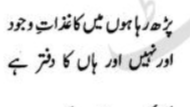

In [3]:
from google.colab import files
from PIL import Image

# Upload an Urdu handwritten image
uploaded = files.upload()

# Get uploaded image name
image_path = list(uploaded.keys())[0]

# Open image
image = Image.open(image_path).convert("RGB")

# Show image
display(image)

In [2]:
!pip install -q sentencepiece
!pip install -q --upgrade transformers tokenizers

In [2]:
!pip install -U sentencepiece tiktoken transformers

In [1]:
import sentencepiece
import tiktoken

print("Packages installed successfully!")

Packages installed successfully!


In [4]:
import torch
from transformers import ViTImageProcessor, RobertaTokenizer, VisionEncoderDecoderModel

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Image processor
image_processor = ViTImageProcessor.from_pretrained(
    "microsoft/trocr-base-printed"
)

# Tokenizer
tokenizer = RobertaTokenizer.from_pretrained(
    "microsoft/trocr-base-printed"
)

# Model
model = VisionEncoderDecoderModel.from_pretrained(
    "Saima-Manzoor/urdu-ocr-codesaviours-si26-saima"
)

model.to(device)
model.eval()

print("Everything loaded successfully!")
print("Device:", device)

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Everything loaded successfully!
Device: cpu


In [7]:
from transformers import RobertaTokenizer

model_name = "Saima-Manzoor/urdu-ocr-codesaviours-si26-saima"

tokenizer = RobertaTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully!")

vocab.json:   0%|          | 0.00/999k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Tokenizer loaded successfully!


In [8]:
import torch

# Convert uploaded image into model input
pixel_values = image_processor(
    images=image,
    return_tensors="pt"
).pixel_values

# Generate prediction
with torch.no_grad():
    generated_ids = model.generate(pixel_values)

# Convert prediction into text
predicted_text = tokenizer.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("Predicted Text:", predicted_text)

/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer RobertaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Predicted Text: 


In [9]:
import torch

# Generate IDs
with torch.no_grad():
    generated_ids = model.generate(
        pixel_values,
        max_new_tokens=50
    )

print("Generated IDs:", generated_ids)

# Decode WITHOUT skipping special tokens
raw_text = tokenizer.batch_decode(
    generated_ids,
    skip_special_tokens=False
)

print("Raw Output:", raw_text)

# Normal decoded text
clean_text = tokenizer.batch_decode(
    generated_ids,
    skip_special_tokens=True
)

print("Clean Output:", clean_text)

Generated IDs: tensor([[2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1]])
Raw Output: ['</s><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad><pad>']
Clean Output: ['']


In [3]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Check Google Drive files and folders
import os

print("Files and folders in MyDrive:\n")

for item in os.listdir("/content/drive/MyDrive"):
    print(item)

Mounted at /content/drive
Files and folders in MyDrive:

GoldenBaked_Instagram_Calendar.gsheet
CamScanner 20-06-2026 13.25_1.jpeg
292839b9-280c-4bfd-b2e7-a42472051a63.jpeg
Classroom
week1_ML_SI-26 (1).gdoc
Colab Notebooks
CodeSaviours
week2_ML_SI-26 (1).gdoc
week1_ML_SI-26.gdoc
week2_ML_SI-26.gdoc
week3_ML_SI-26 (3).gdoc
week3_ML_SI-26 (2).gdoc
week3_ML_SI-26 (1).gdoc
week4_ML_SI-26 (1).gdoc
SI26-urdu-ocr-model
week5_ML_SI-26 (2).gdoc
week5_ML_SI-26 (1).gdoc
week3_ML_SI-26.gdoc
week4_ML_SI-26.gdoc
week5_ML_SI-26.gdoc
week6_ML_SI-26.gdoc
week7_ML_SI-26.gdoc
week8_ML_SI-26.gdoc


In [4]:
import os

model_path = "/content/drive/MyDrive/SI26-urdu-ocr-model"

print("Folder exists:", os.path.exists(model_path))
print("\nFiles inside the model folder:\n")

for root, dirs, files in os.walk(model_path):
    level = root.replace(model_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

Folder exists: True

Files inside the model folder:

SI26-urdu-ocr-model/
    config.json
    generation_config.json
    model.safetensors
    tokenizer_config.json
    preprocessor_config.json
    vocab.json
    special_tokens_map.json
    merges.txt


In [7]:
!pip install -q huggingface_hub

from huggingface_hub import login, HfApi

login()

api = HfApi()

api.create_repo(
    repo_id="Saima-Manzoor/urdu-ocr-codesaviours-si26-saima",
    repo_type="model",
    exist_ok=True
)

api.upload_folder(
    folder_path="/content/drive/MyDrive/SI26-urdu-ocr-model",
    repo_id="Saima-Manzoor/urdu-ocr-codesaviours-si26-saima",
    repo_type="model"
)

print("Model uploaded successfully!")

No files have been modified since last commit. Skipping to prevent empty commit.


Model uploaded successfully!


In [5]:
from huggingface_hub import HfApi

api = HfApi()

api.upload_folder(
    folder_path="/content/drive/MyDrive/SI26-urdu-ocr-model",
    repo_id="Saima-Manzoor/urdu-ocr-codesaviours-si26-saima",
    repo_type="model"
)

print("Model uploaded successfully!")

Model uploaded successfully!


In [3]:
!pip install -q sentencepiece

In [ ]:
from transformers import VisionEncoderDecoderModel, TrOCRProcessor

model_name = "Saima-Manzoor/urdu-ocr-codesaviours-si26-saima"

processor = TrOCRProcessor.from_pretrained(model_name)
model = VisionEncoderDecoderModel.from_pretrained(model_name)

print("Model loaded successfully!")